Lab 2: BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU

phần 1

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

print("Câu 1")
print(df.sort_values(by='DH1')[['DH1']])

print("\nCâu 2")
print(df.sort_values(by=['GT', 'DH2'])[['GT', 'DH2']])

Q1 = lambda x: x.quantile(0.25)
Q2 = lambda x: x.quantile(0.50)
Q3 = lambda x: x.quantile(0.75)

print("\nCâu 3")

pivot1 = pd.pivot_table(
    df,
    values='DH1',
    index='KT',
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot1)

print("\nCâu 4")

pivot2 = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot2)

print("\nCâu 5")

pivot3 = pd.pivot_table(
    df,
    values='DH1',
    index=['KT', 'KV', 'DT'],
    aggfunc=[
        'count',
        'sum',
        'mean',
        'median',
        'min',
        'max',
        'std',
        Q1,
        Q2,
        Q3
    ]
)

print(pivot3)

Câu 1
     DH1
53  1.00
43  1.25
5   1.50
72  1.50
83  1.75
..   ...
6   6.50
11  6.75
23  6.75
24  7.00
97  7.00

[100 rows x 1 columns]

Câu 2
   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75
.. ..   ...
68  M  6.00
11  M  6.50
47  M  6.50
2   M  6.75
97  M  8.00

[100 rows x 2 columns]

Câu 3
   count     sum      mean median   min   max       std <lambda>             
     DH1     DH1       DH1    DH1   DH1   DH1       DH1      DH1   DH1    DH1
KT                                                                           
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296   2.2500  3.25  4.250
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201   2.1875  3.00  3.250
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905   3.2500  3.50  3.750
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209   5.0625  5.25  6.375
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146   3.0000  3.75  4.875

Câu 4
       count    sum      mean median   min   max 

phần 2

Câu 1
GT
M    52
F    48
Name: count, dtype: int64
GT
M    0.52
F    0.48
Name: proportion, dtype: float64


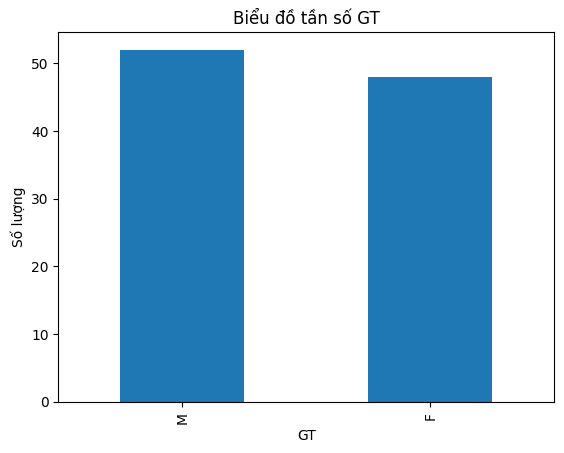

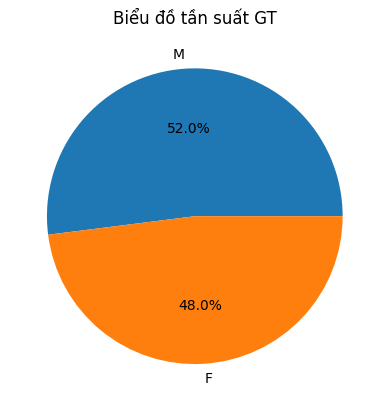

Câu 2


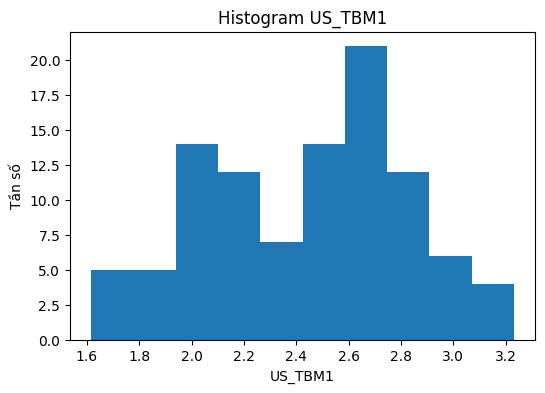

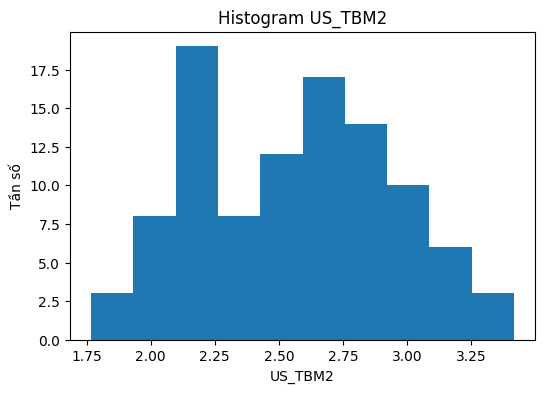

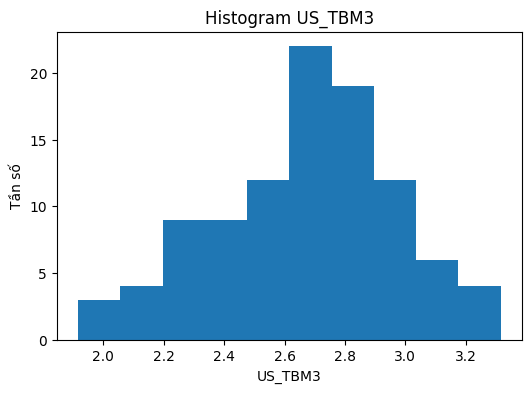

Câu 3
DT
0.0    50
1.0     1
6.0     1
Name: count, dtype: int64


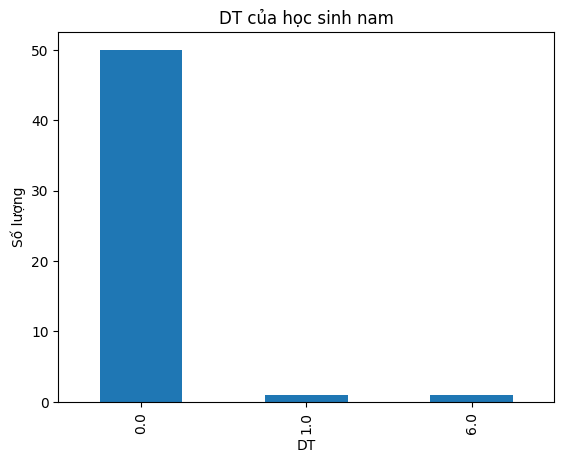

Câu 4
KV
1      2
2      2
2NT    2
Name: count, dtype: int64


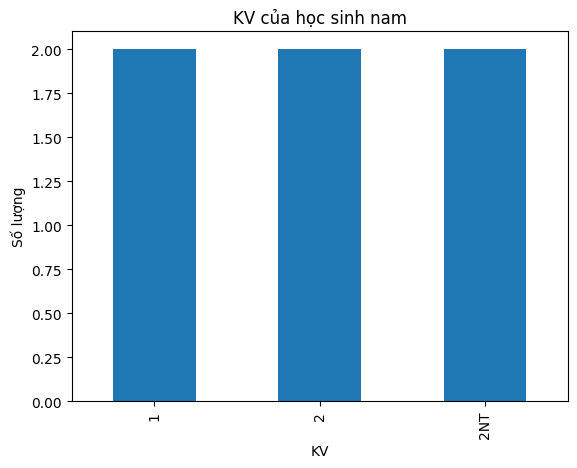

Câu 5


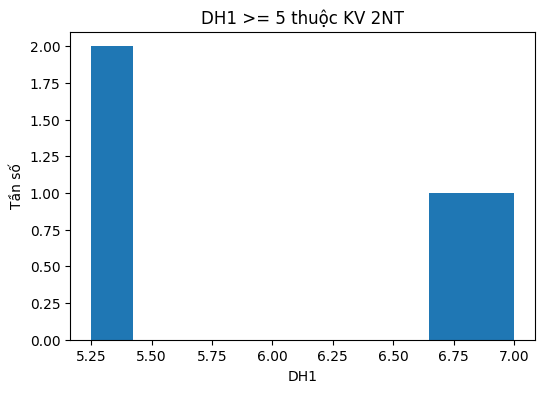

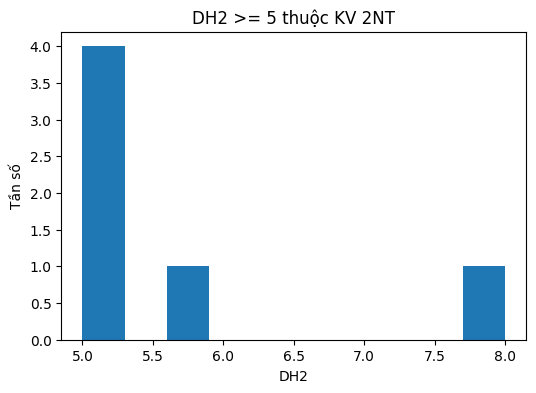

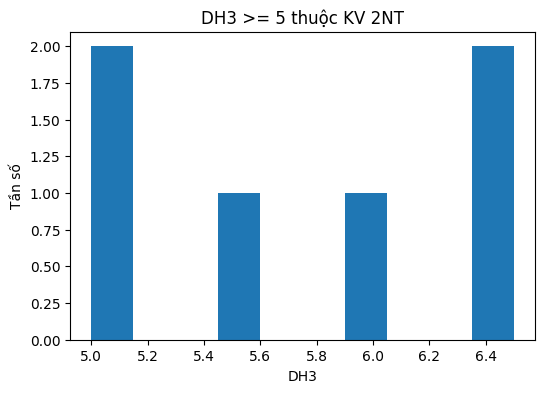

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

print("Câu 1")

tan_so_gt = df['GT'].value_counts()
print(tan_so_gt)

tan_suat_gt = df['GT'].value_counts(normalize=True)
print(tan_suat_gt)

tan_so_gt.plot(kind='bar')
plt.title("Biểu đồ tần số GT")
plt.xlabel("GT")
plt.ylabel("Số lượng")
plt.show()

tan_so_gt.plot(kind='pie', autopct='%1.1f%%')
plt.title("Biểu đồ tần suất GT")
plt.ylabel("")
plt.show()

print("Câu 2")

for col in ['US_TBM1', 'US_TBM2', 'US_TBM3']:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=10)
    plt.title(f"Histogram {col}")
    plt.xlabel(col)
    plt.ylabel("Tần số")
    plt.show()

print("Câu 3")

nam = df[df['GT'] == 'M']

print(nam['DT'].value_counts())

if not nam.empty:
    nam['DT'].value_counts().plot(kind='bar')
    plt.title("DT của học sinh nam")
    plt.xlabel("DT")
    plt.ylabel("Số lượng")
    plt.show()

print("Câu 4")

dk = df[
    (df['GT'] == 'M') &
    (df['DH1'] >= 5.0) &
    (df['DH2'] >= 4.0) &
    (df['DH3'] >= 4.0)
]

print(dk['KV'].value_counts())

if not dk.empty:
    dk['KV'].value_counts().plot(kind='bar')
    plt.title("KV của học sinh nam")
    plt.xlabel("KV")
    plt.ylabel("Số lượng")
    plt.show()
else:
    print("Không có dữ liệu phù hợp")

print("Câu 5")

kv2nt = df[df['KV'] == '2NT']

for col in ['DH1', 'DH2', 'DH3']:

    data = kv2nt[kv2nt[col] >= 5.0]

    plt.figure(figsize=(6,4))
    plt.hist(data[col], bins=10)

    plt.title(f"{col} >= 5 thuộc KV 2NT")
    plt.xlabel(col)
    plt.ylabel("Tần số")

    plt.show()

phần 3

Câu 1
    XL1  XL2   XL3
G     1    2   1.0
K    24   30  35.0
TB   18   15  12.0
Y     5    1   0.0


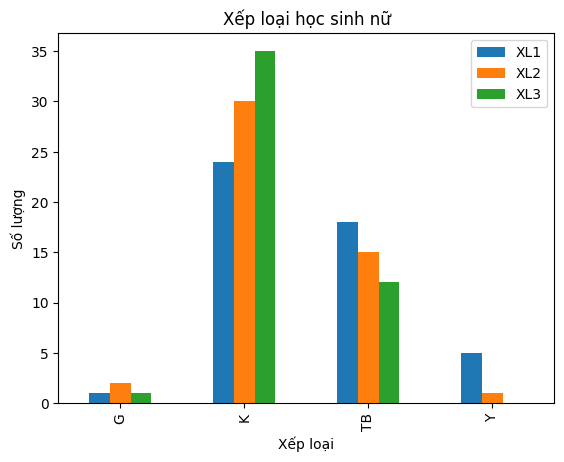

Câu 2
KQXT  0.0  1.0
KT            
A      45    4
A1      6    0
B       9    0


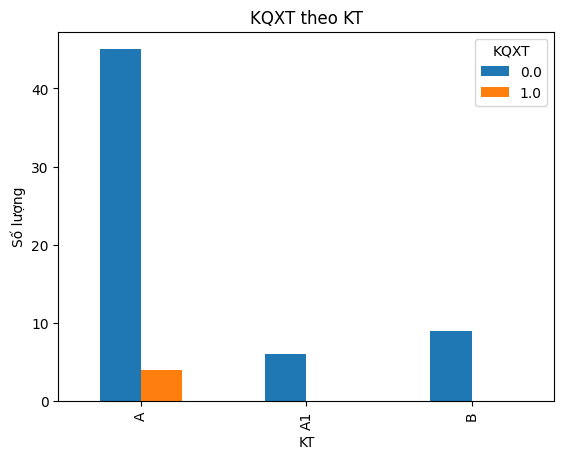

Câu 3
KV   1  2  2NT
KT            
A   29  9   11
A1   2  0    4
B    8  0    1
C    8  2    4
D1  13  8    1


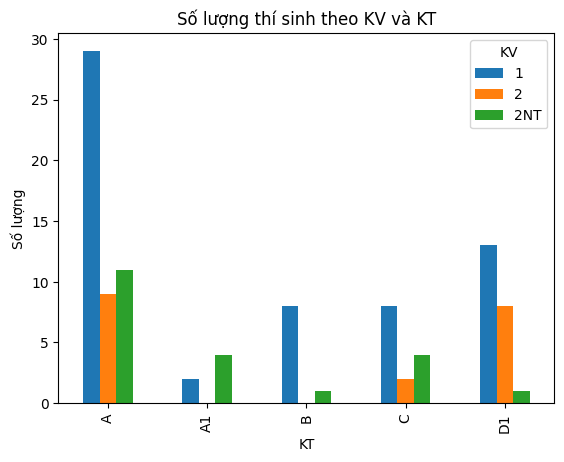

Câu 4
KQXT  0.0  1.0
KT            
A      45    4
A1      6    0
B       9    0
C      10    4
D1     20    2


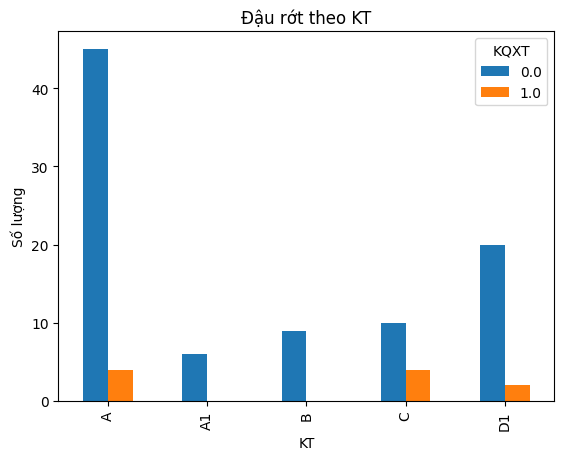

Câu 5
KQXT  0.0  1.0
KV            
1      57    3
2      14    5
2NT    19    2


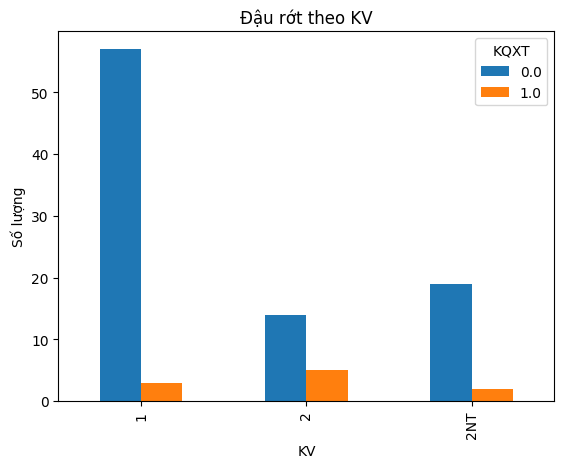

Câu 6
KQXT  0.0  1.0
DT            
0.0    87   10
1.0     2    0
6.0     1    0


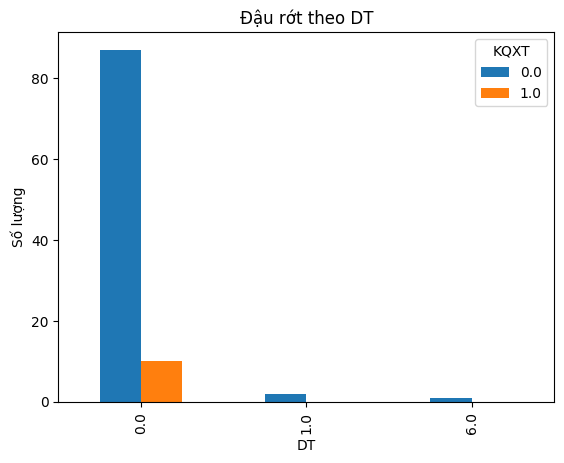

Câu 7
KQXT  0.0  1.0
GT            
F      45    3
M      45    7


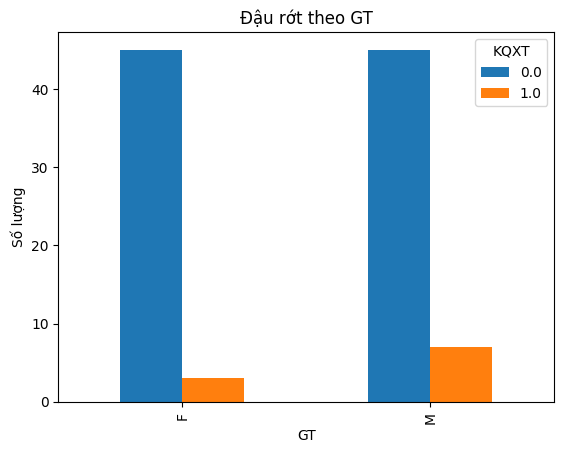

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

print("Câu 1")

nu = df[df['GT'] == 'F']

if not nu.empty:

    xl1 = nu['XL1'].value_counts()
    xl2 = nu['XL2'].value_counts()
    xl3 = nu['XL3'].value_counts()

    bang1 = pd.DataFrame({
        'XL1': xl1,
        'XL2': xl2,
        'XL3': xl3
    }).fillna(0)

    print(bang1)

    bang1.plot(kind='bar')

    plt.title("Xếp loại học sinh nữ")
    plt.xlabel("Xếp loại")
    plt.ylabel("Số lượng")

    plt.show()

else:
    print("Không có dữ liệu nữ")

print("Câu 2")

data2 = df[df['KT'].isin(['A', 'A1', 'B'])]

if not data2.empty:

    bang2 = pd.crosstab(data2['KT'], data2['KQXT'])

    print(bang2)

    bang2.plot(kind='bar')

    plt.title("KQXT theo KT")
    plt.xlabel("KT")
    plt.ylabel("Số lượng")

    plt.show()

else:
    print("Không có dữ liệu phù hợp")

print("Câu 3")

bang3 = pd.crosstab(df['KT'], df['KV'])

print(bang3)

bang3.plot(kind='bar')

plt.title("Số lượng thí sinh theo KV và KT")
plt.xlabel("KT")
plt.ylabel("Số lượng")

plt.show()

print("Câu 4")

bang4 = pd.crosstab(df['KT'], df['KQXT'])

print(bang4)

bang4.plot(kind='bar')

plt.title("Đậu rớt theo KT")
plt.xlabel("KT")
plt.ylabel("Số lượng")

plt.show()

print("Câu 5")

bang5 = pd.crosstab(df['KV'], df['KQXT'])

print(bang5)

bang5.plot(kind='bar')

plt.title("Đậu rớt theo KV")
plt.xlabel("KV")
plt.ylabel("Số lượng")

plt.show()

print("Câu 6")

bang6 = pd.crosstab(df['DT'], df['KQXT'])

print(bang6)

bang6.plot(kind='bar')

plt.title("Đậu rớt theo DT")
plt.xlabel("DT")
plt.ylabel("Số lượng")

plt.show()

print("Câu 7")

bang7 = pd.crosstab(df['GT'], df['KQXT'])

print(bang7)

bang7.plot(kind='bar')

plt.title("Đậu rớt theo GT")
plt.xlabel("GT")
plt.ylabel("Số lượng")

plt.show()

phần 4

Câu 1


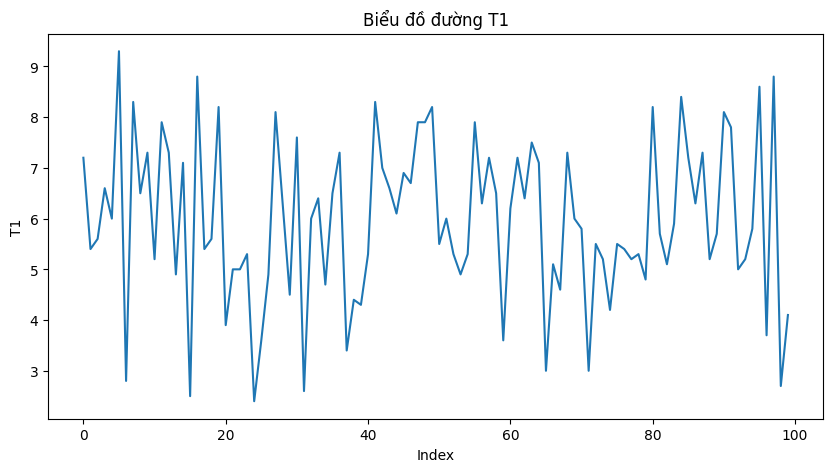

Câu 2
    T1 phanlopt1
0  7.2       kha
1  5.4        tb
2  5.6        tb
3  6.6        tb
4  6.0        tb
Câu 3
phanlopt1
tb      46
kem     23
kha     19
gioi    12
Name: count, dtype: int64


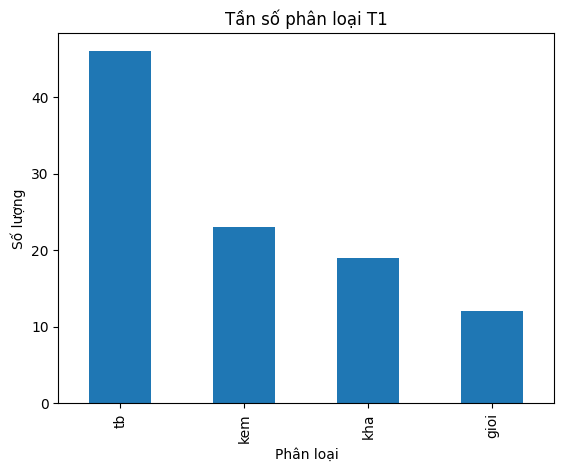

Câu 4


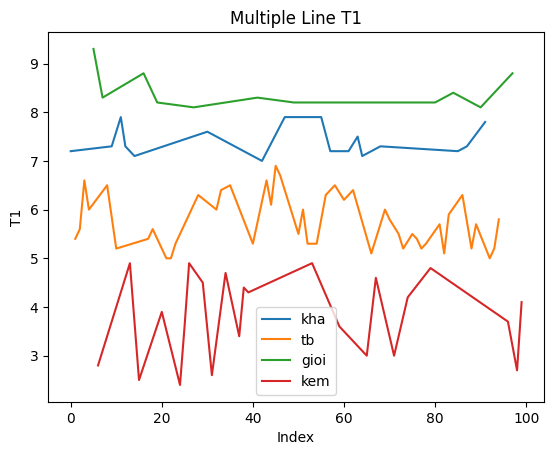

Câu 5


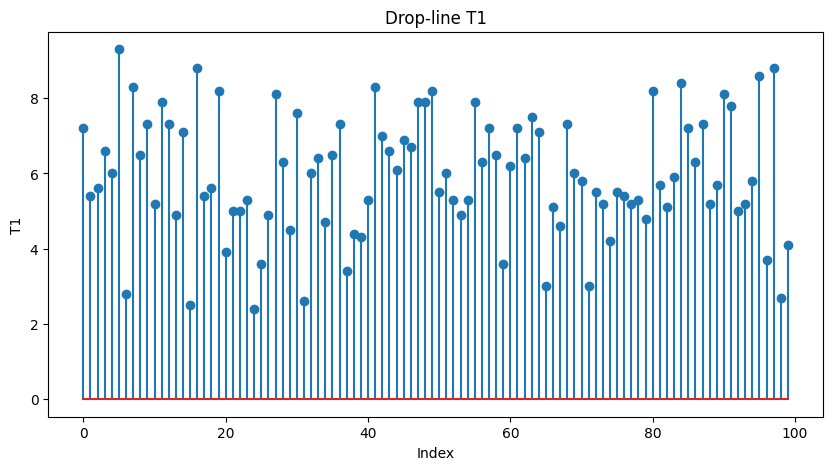

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

print("Câu 1")

plt.figure(figsize=(10,5))

plt.plot(df['T1'])

plt.title("Biểu đồ đường T1")
plt.xlabel("Index")
plt.ylabel("T1")

plt.show()

print("Câu 2")

def phanloai(x):

    if x < 5:
        return 'kem'

    elif x < 7:
        return 'tb'

    elif x < 8:
        return 'kha'

    else:
        return 'gioi'

df['phanlopt1'] = df['T1'].apply(phanloai)

print(df[['T1', 'phanlopt1']].head())

print("Câu 3")

print(df['phanlopt1'].value_counts())

df['phanlopt1'].value_counts().plot(kind='bar')

plt.title("Tần số phân loại T1")
plt.xlabel("Phân loại")
plt.ylabel("Số lượng")

plt.show()

print("Câu 4")

for loai in df['phanlopt1'].unique():

    data = df[df['phanlopt1'] == loai]

    plt.plot(data.index, data['T1'], label=loai)

plt.legend()

plt.title("Multiple Line T1")
plt.xlabel("Index")
plt.ylabel("T1")

plt.show()

print("Câu 5")

plt.figure(figsize=(10,5))

plt.stem(df.index, df['T1'])

plt.title("Drop-line T1")
plt.xlabel("Index")
plt.ylabel("T1")

plt.show()

phần 5

PHẦN 5
Câu 1
count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
Mean: 5.946000000000001
Median: 5.85
Mode: 5.2
Variance: 2.5867515151515157
Std: 1.6083381221470552


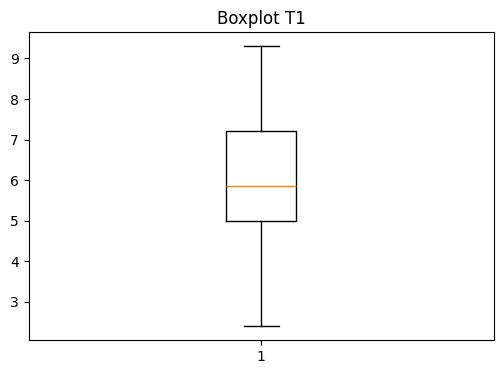

Min: 2.4
Q1: 5.0
Median: 5.85
Q3: 7.2
Max: 9.3
IQR: 2.2
Lower Bound: 1.6999999999999997
Upper Bound: 10.5


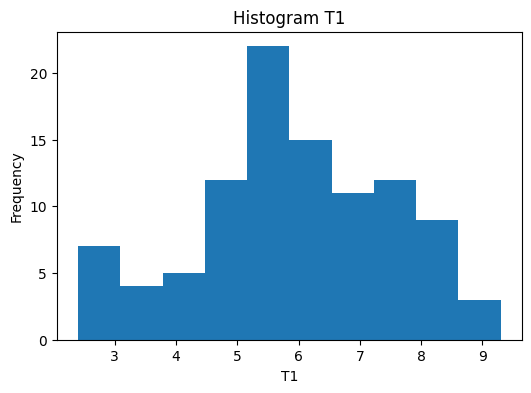

Skewness: -0.1755583084327443
Kurtosis: -0.5158380739199266


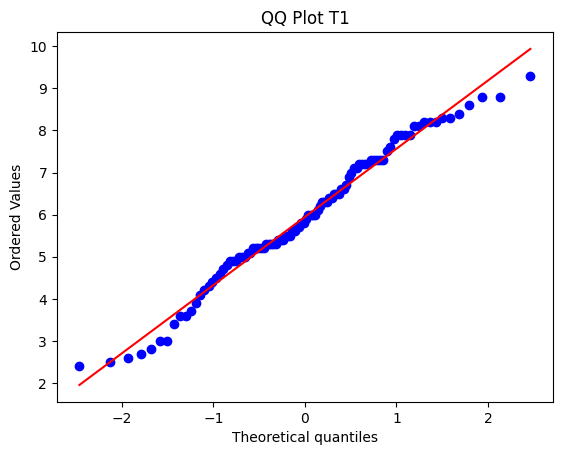

Câu 2


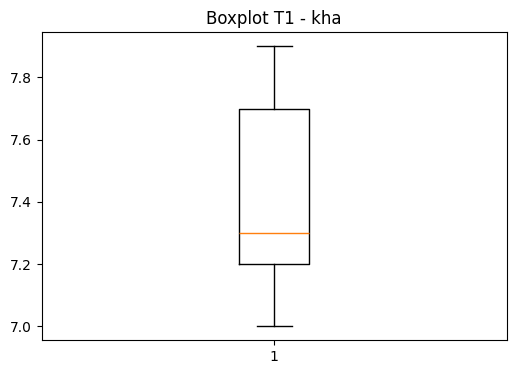

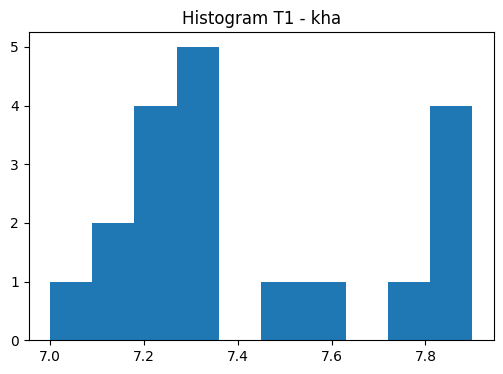

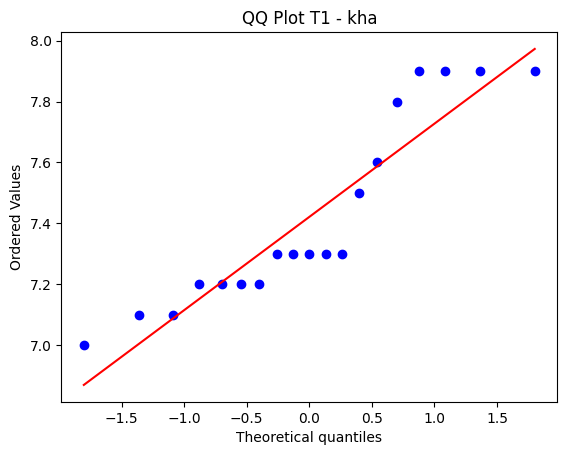

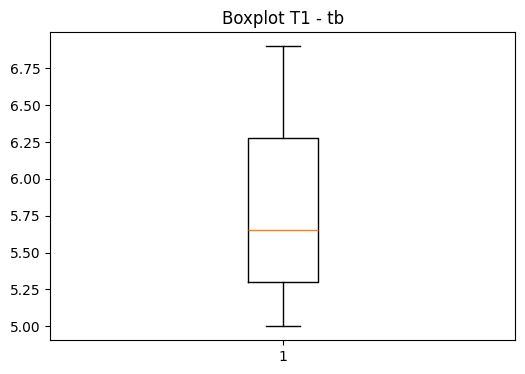

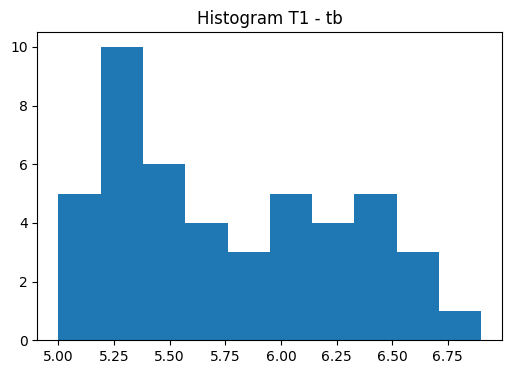

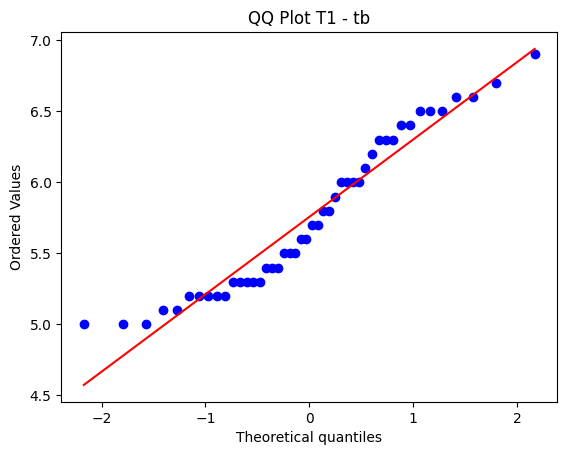

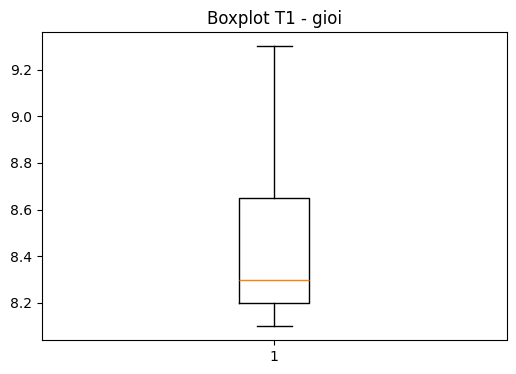

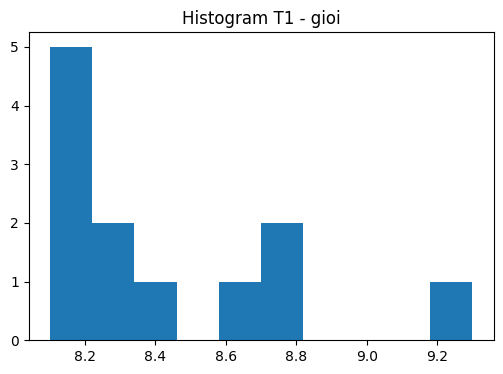

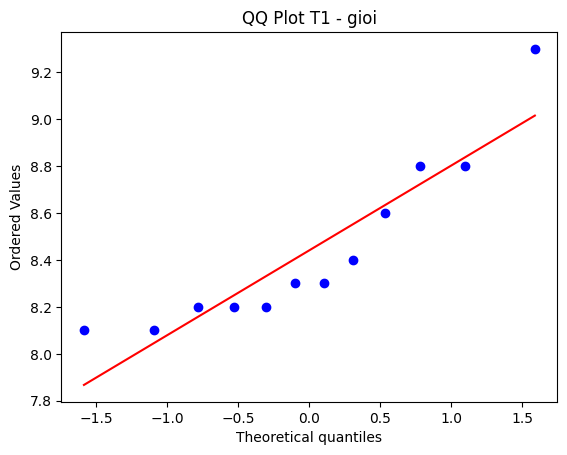

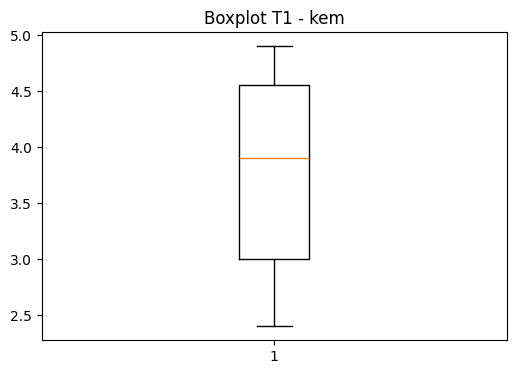

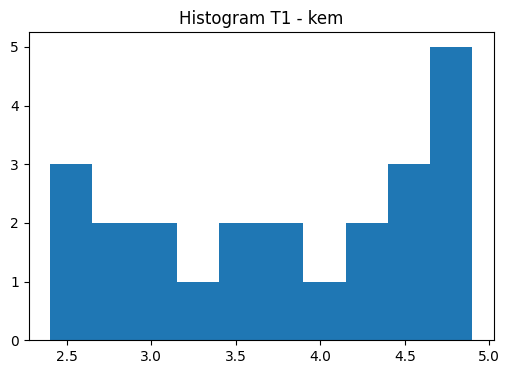

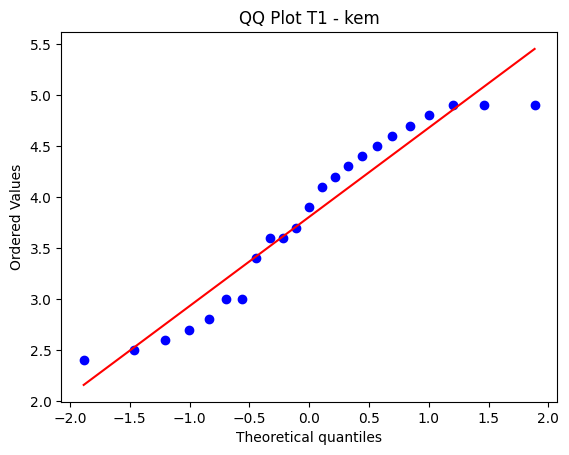

Câu 3
Covariance: 0.11283838383838381
Correlation: 0.04925439216104145


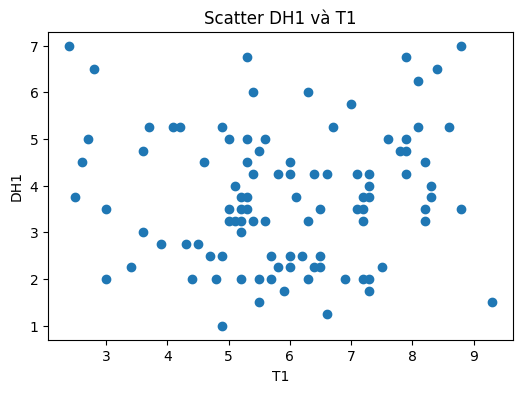

Câu 4
KV: 2NT Correlation: 0.27846919397449776


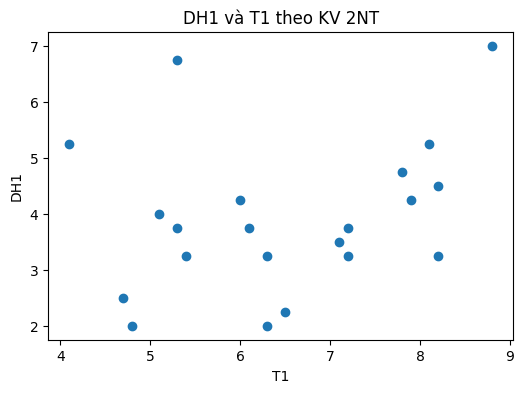

KV: 1 Correlation: -0.07984936277357216


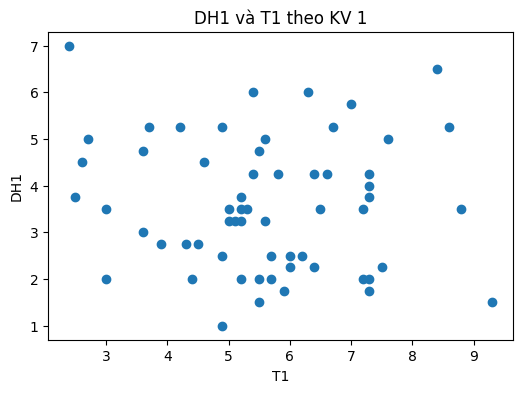

KV: 2 Correlation: 0.06174287535779778


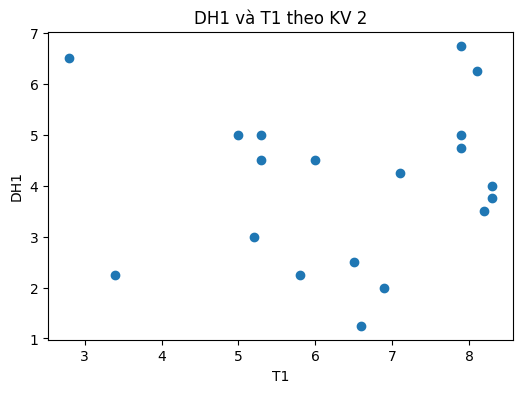

Câu 5
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


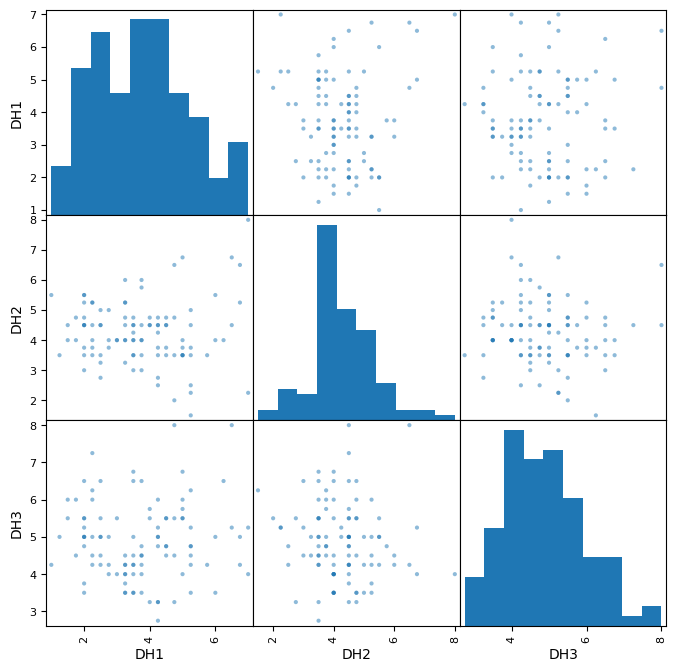

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

print("PHẦN 5")

print("Câu 1")

print(df['T1'].describe())

mean_t1 = df['T1'].mean()
median_t1 = df['T1'].median()
mode_t1 = df['T1'].mode()[0]
var_t1 = df['T1'].var()
std_t1 = df['T1'].std()

print("Mean:", mean_t1)
print("Median:", median_t1)
print("Mode:", mode_t1)
print("Variance:", var_t1)
print("Std:", std_t1)

plt.figure(figsize=(6,4))

plt.boxplot(df['T1'])

plt.title("Boxplot T1")

plt.show()

Q1 = df['T1'].quantile(0.25)
Q2 = df['T1'].quantile(0.50)
Q3 = df['T1'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Min:", df['T1'].min())
print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)
print("Max:", df['T1'].max())
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

plt.figure(figsize=(6,4))

plt.hist(df['T1'], bins=10)

plt.title("Histogram T1")
plt.xlabel("T1")
plt.ylabel("Frequency")

plt.show()

skewness = stats.skew(df['T1'])
kurtosis = stats.kurtosis(df['T1'])

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

stats.probplot(df['T1'], dist="norm", plot=plt)

plt.title("QQ Plot T1")

plt.show()

print("Câu 2")

if 'phanlopt1' not in df.columns:

    def phanloai(x):

        if x < 5:
            return 'kem'

        elif x < 7:
            return 'tb'

        elif x < 8:
            return 'kha'

        else:
            return 'gioi'

    df['phanlopt1'] = df['T1'].apply(phanloai)

groups = df['phanlopt1'].unique()

for g in groups:

    data = df[df['phanlopt1'] == g]['T1']

    plt.figure(figsize=(6,4))

    plt.boxplot(data)

    plt.title(f"Boxplot T1 - {g}")

    plt.show()

    plt.figure(figsize=(6,4))

    plt.hist(data, bins=10)

    plt.title(f"Histogram T1 - {g}")

    plt.show()

    stats.probplot(data, dist="norm", plot=plt)

    plt.title(f"QQ Plot T1 - {g}")

    plt.show()

print("Câu 3")

cov = df['DH1'].cov(df['T1'])
corr = df['DH1'].corr(df['T1'])

print("Covariance:", cov)
print("Correlation:", corr)

plt.figure(figsize=(6,4))

plt.scatter(df['T1'], df['DH1'])

plt.title("Scatter DH1 và T1")
plt.xlabel("T1")
plt.ylabel("DH1")

plt.show()

print("Câu 4")

for kv in df['KV'].unique():

    data = df[df['KV'] == kv]

    corr_kv = data['DH1'].corr(data['T1'])

    print("KV:", kv, "Correlation:", corr_kv)

    plt.figure(figsize=(6,4))

    plt.scatter(data['T1'], data['DH1'])

    plt.title(f"DH1 và T1 theo KV {kv}")
    plt.xlabel("T1")
    plt.ylabel("DH1")

    plt.show()

print("Câu 5")

corr_matrix = df[['DH1', 'DH2', 'DH3']].corr()

print(corr_matrix)

pd.plotting.scatter_matrix(
    df[['DH1', 'DH2', 'DH3']],
    figsize=(8,8)
)

plt.show()